In [40]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neural_net import NeuralNet
import mushrooms as shroom
import graphics
from sklearn.datasets import fetch_openml

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
mnist = fetch_openml('mnist_784', as_frame=False)

X, y = mnist.data, mnist.target

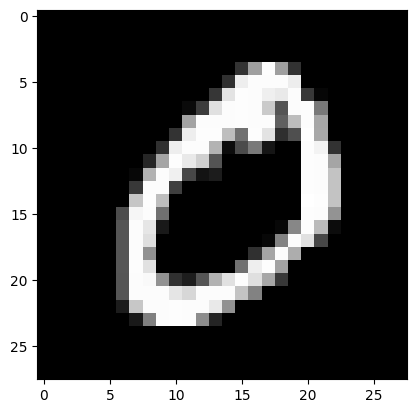

In [ ]:
X = np.array(X)
X_image = np.swapaxes(np.array(np.split(X, 28, axis=1)), 1, 0)
plt.imshow(X_image[1], cmap="gray_r")

y = np.astype(y, int)
y_processed = np.zeros((len(y), 10))
for i, y_p in enumerate(y_processed):
    y_p[y[i]] =1

y = y_processed 
X = X/255

neural_net = NeuralNet((28**2, 32, 10), learning_rate=0.0005, random_state=42)

In [43]:
X.shape

(70000, 784)

In [44]:
neural_net.layers[0].activation_method="ReLu"
losses, y_pred = neural_net.batch_train_optimized(X[0:5000], y[0:5000], 300, 32)


c:\Users\EIpro\Programming\Python\2026\Neural_Net\lib\layer.py:61: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-X))


EPOCH: 0    LOSS: 2.651073593161427    MOMENTUM: 1.02
EPOCH: 1    LOSS: 1.5382785611468557    MOMENTUM: 1.0404
EPOCH: 2    LOSS: 1.4024825785586217    MOMENTUM: 1.061208
EPOCH: 3    LOSS: 1.301861260654386    MOMENTUM: 1.08243216
EPOCH: 4    LOSS: 1.2082262165213784    MOMENTUM: 1.1040808032
EPOCH: 5    LOSS: 1.12060462650803    MOMENTUM: 1.126162419264
EPOCH: 6    LOSS: 1.0519959498255211    MOMENTUM: 1.14868566764928
EPOCH: 7    LOSS: 0.9875566297316232    MOMENTUM: 1.1716593810022657
EPOCH: 8    LOSS: 0.9294564105413903    MOMENTUM: 1.195092568622311
EPOCH: 9    LOSS: 0.8777708976415263    MOMENTUM: 1.2189944199947573
EPOCH: 10    LOSS: 0.8302733118843855    MOMENTUM: 1.2433743083946525
EPOCH: 11    LOSS: 0.7895164131184966    MOMENTUM: 1.2682417945625455
EPOCH: 12    LOSS: 0.7540573152004558    MOMENTUM: 1.2936066304537963
EPOCH: 13    LOSS: 0.725899016866671    MOMENTUM: 1.3194787630628724
EPOCH: 14    LOSS: 0.7020026790724716    MOMENTUM: 1.3458683383241299
EPOCH: 15    LOSS: 0.6

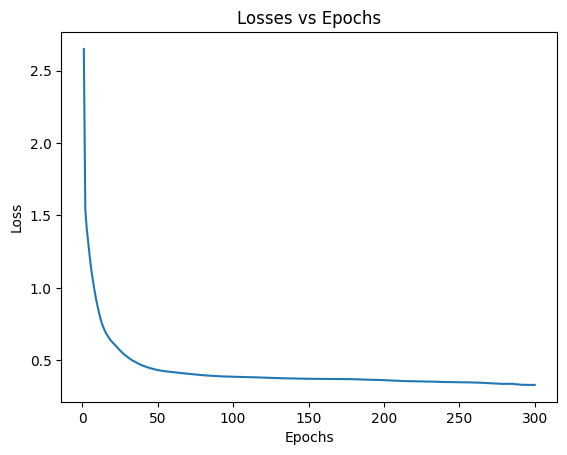

array([[0.09761488, 0.09761488, 0.09761488, ..., 0.09761488, 0.09761488,
        0.09761488],
       [0.12994442, 0.12994442, 0.12994442, ..., 0.12994442, 0.12994442,
        0.12994442],
       [0.08638562, 0.08638562, 0.08638562, ..., 0.08638562, 0.08638562,
        0.08638562],
       ...,
       [0.11777032, 0.11777032, 0.11777032, ..., 0.11777032, 0.11777032,
        0.11777032],
       [0.08698156, 0.08698156, 0.08698156, ..., 0.08698156, 0.08698156,
        0.08698156],
       [0.10116102, 0.10116102, 0.10116102, ..., 0.10116102, 0.10116102,
        0.10116102]], shape=(10, 70000))

In [59]:
graphics.plot_losses(300, losses)
y_pred[0]
neural_net.batch_eval(X)

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (10,) and arg 1 with shape (10, 32).

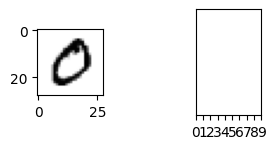

In [60]:
def plot_value_array(i, predictions_array, true_label):
  #true_label = true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  #thisplot[true_label].set_color('blue')
w = 8
h = 8
fig = plt.figure(figsize=(8, 8))
columns = 4
rows = 5
for i in range(1, columns*rows +1):
    plt.subplot(rows, 2*columns, 2*i)
    plt.imshow(X_image[i], cmap="gray_r")
    #plot_image(i, predictions[i], test_labels, test_images)
    plt.subplot(rows, 2*columns, 2*i+2)
    plot_value_array(i, y_pred[0], y[i].astype(int))
plt.show()